In [ ]:
#Smit Patel Contribution 
# first prompt: Eplain me how it works and steps for it  Causal transformer model using learnable embedding layer and position encodings
# last prompt: how can I tune model give me best possible ways

In [1]:
# ------------------------------
# Causal Transformer Model (Autoregressive)
# Using Learnable Embedding + Learnable Position Encoding
# Task: Tweet Sentiment Classification (Positive, Negative, Neutral)
# ------------------------------

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ------------------------------
# Step 1: Load Data
# ------------------------------
train_df = pd.read_csv("cleaned_train_balanced.csv")
test_df = pd.read_csv("cleaned_test.csv")

In [4]:
print("Train Columns:", train_df.columns.tolist())
print("Test Columns:", test_df.columns.tolist())


Train Columns: ['tweet', 'clean_tweet', 'sentiment']
Test Columns: ['tweet', 'clean_tweet', 'sentiment']


In [5]:
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_df['sentiment'])
y_test = label_encoder.transform(test_df['sentiment'])

In [6]:
# Convert to one-hot
y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)

In [8]:
# ------------------------------
# Step 3: Tokenizer on Train Only (Handle floats safely)
# ------------------------------
train_df['clean_tweet'] = train_df['clean_tweet'].astype(str)
test_df['clean_tweet'] = test_df['clean_tweet'].astype(str)

In [9]:
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['clean_tweet'])

X_train_seq = tokenizer.texts_to_sequences(train_df['clean_tweet'])
X_test_seq = tokenizer.texts_to_sequences(test_df['clean_tweet'])

MAXLEN = 100
X_train = pad_sequences(X_train_seq, maxlen=MAXLEN, padding='post')
X_test = pad_sequences(X_test_seq, maxlen=MAXLEN, padding='post')

vocab_size = len(tokenizer.word_index) + 1

In [10]:
# ------------------------------
# Step 4: Define Layers
# ------------------------------
class LearnablePositionEncoding(tf.keras.layers.Layer):
    def __init__(self, maxlen, embed_dim):
        super().__init__()
        self.pos_emb = tf.keras.layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        pos = tf.range(start=0, limit=tf.shape(x)[1], delta=1)
        pos_encoding = self.pos_emb(pos)
        return x + pos_encoding

class CausalTransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation='relu'),
            tf.keras.layers.Dense(embed_dim)
        ])
        self.norm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(dropout)
        self.dropout2 = tf.keras.layers.Dropout(dropout)

    def call(self, inputs, training):
        mask = tf.linalg.band_part(tf.ones((tf.shape(inputs)[1], tf.shape(inputs)[1])), -1, 0)
        attn_output = self.att(inputs, inputs, attention_mask=mask)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.norm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.norm2(out1 + ffn_output)


In [12]:
# ------------------------------
# Step 5: Build Model
# ------------------------------
embedding_dim = 128
ff_dim = 256
num_heads = 4

inputs = tf.keras.Input(shape=(MAXLEN,))
embedding = tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim)(inputs)
pos_encoding = LearnablePositionEncoding(MAXLEN, embedding_dim)(embedding)
transformer = CausalTransformerBlock(embedding_dim, num_heads, ff_dim)(pos_encoding, training=True)
pooled = tf.keras.layers.GlobalAveragePooling1D()(transformer)
dropout = tf.keras.layers.Dropout(0.3)(pooled)
outputs = tf.keras.layers.Dense(3, activation='softmax')(dropout)

model = tf.keras.Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding_2 (Embedding)              │ (None, 100, 128)            │      10,678,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ learnable_position_encoding_1        │ (None, 100, 128)            │          12,800 │
│ (LearnablePositionEncoding)          │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ causal_transformer_block_1           │ (None, 100, 128)            │         330,240 │
│ (CausalTransformerBlock)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,021,699 (42.04 MB)

 Trainable params: 11,021,699 (42.04 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# ------------------------------
# Step 6: Train Model
# ------------------------------
history = model.fit(X_train, y_train_cat, epochs=5, batch_size=64, validation_split=0.1)

Epoch 1/5
2592/2592 ━━━━━━━━━━━━━━━━━━━━ 485s 183ms/step - accuracy: 0.6326 - loss: 0.8085 - val_accuracy: 0.7448 - val_loss: 0.5998
Epoch 2/5
2592/2592 ━━━━━━━━━━━━━━━━━━━━ 438s 169ms/step - accuracy: 0.7800 - loss: 0.5249 - val_accuracy: 0.7546 - val_loss: 0.5834
Epoch 3/5
2592/2592 ━━━━━━━━━━━━━━━━━━━━ 426s 164ms/step - accuracy: 0.8201 - loss: 0.4346 - val_accuracy: 0.7567 - val_loss: 0.6357
Epoch 4/5
2592/2592 ━━━━━━━━━━━━━━━━━━━━ 428s 165ms/step - accuracy: 0.8560 - loss: 0.3605 - val_accuracy: 0.7552 - val_loss: 0.6955
Epoch 5/5
2592/2592 ━━━━━━━━━━━━━━━━━━━━ 431s 166ms/step - accuracy: 0.8805 - loss: 0.3013 - val_accuracy: 0.7509 - val_loss: 0.7433


2821/2821 ━━━━━━━━━━━━━━━━━━━━ 77s 27ms/step

Classification Report:
              precision    recall  f1-score   support

    Negative       0.63      0.76      0.69     15301
     Neutral       0.56      0.69      0.62     15358
    Positive       0.92      0.82      0.87     59608

    accuracy                           0.79     90267
   macro avg       0.71      0.76      0.73     90267
weighted avg       0.81      0.79      0.80     90267


Confusion Matrix:


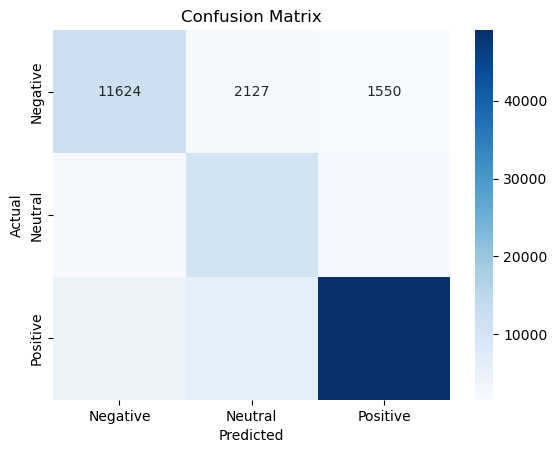


Multiclass ROC AUC: 0.9040


In [14]:
# ------------------------------
# Step 7: Evaluate
# ------------------------------
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

print("\nConfusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

auc_score = roc_auc_score(y_test_cat, y_pred_proba, multi_class='ovr')
print(f"\nMulticlass ROC AUC: {auc_score:.4f}")


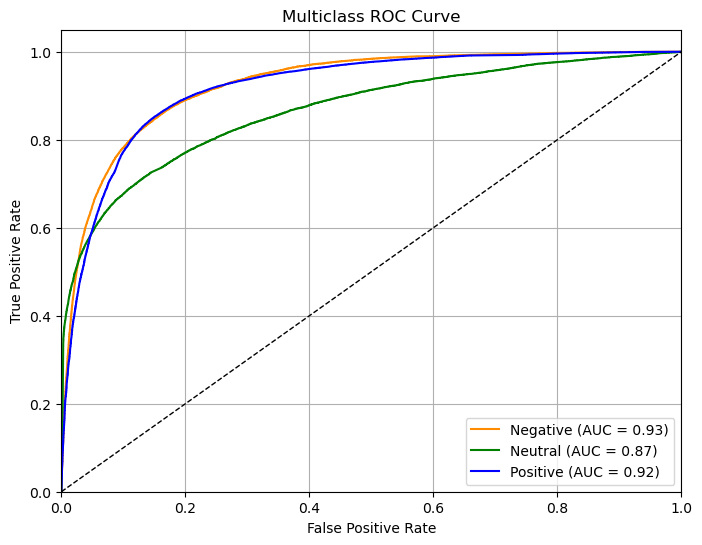

In [15]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Binarize the true labels for multiclass ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])  # Negative=0, Neutral=1, Positive=2

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(8, 6))
colors = ['darkorange', 'green', 'blue']
labels = label_encoder.classes_  # ['Negative', 'Neutral', 'Positive']

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"{labels[i]} (AUC = {roc_auc[i]:.2f})", color=colors[i])

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [16]:
from tensorflow.keras.callbacks import EarlyStopping
import time

# Updated Hyperparameters
embedding_dim = 256       # increased from 128
ff_dim = 512              # increased from 256
num_heads = 8             # increased from 4
dropout_rate = 0.2
epochs = 10
batch_size = 64

# Build Model Function
def build_causal_transformer(vocab_size, maxlen, embedding_dim, ff_dim, num_heads, dropout_rate):
    inputs = tf.keras.Input(shape=(maxlen,))
    embedding = tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim)(inputs)
    pos_encoding = LearnablePositionEncoding(maxlen, embedding_dim)(embedding)
    transformer = CausalTransformerBlock(embedding_dim, num_heads, ff_dim, dropout=dropout_rate)(pos_encoding, training=True)
    pooled = tf.keras.layers.GlobalAveragePooling1D()(transformer)
    dropout = tf.keras.layers.Dropout(dropout_rate)(pooled)
    outputs = tf.keras.layers.Dense(3, activation='softmax')(dropout)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Instantiate model
model_tuned = build_causal_transformer(vocab_size, MAXLEN, embedding_dim, ff_dim, num_heads, dropout_rate)
model_tuned.summary()

# EarlyStopping Callback
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Train the model
start_time = time.time()
history_tuned = model_tuned.fit(
    X_train, y_train_cat,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
end_time = time.time()
print(f"Training time: {(end_time - start_time)/60:.2f} minutes")


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding_4 (Embedding)              │ (None, 100, 256)            │      21,356,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ learnable_position_encoding_2        │ (None, 100, 256)            │          25,600 │
│ (LearnablePositionEncoding)          │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ causal_transformer_block_2           │ (None, 100, 256)            │       2,367,488 │
│ (CausalTransformerBlock)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d_1           │ (None, 256)                 │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 3)                   │             771 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,750,403 (90.60 MB)

 Trainable params: 23,750,403 (90.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2592/2592 ━━━━━━━━━━━━━━━━━━━━ 2043s 784ms/step - accuracy: 0.6344 - loss: 0.8416 - val_accuracy: 0.7388 - val_loss: 0.6109
Epoch 2/10
2592/2592 ━━━━━━━━━━━━━━━━━━━━ 1995s 770ms/step - accuracy: 0.7829 - loss: 0.5174 - val_accuracy: 0.7605 - val_loss: 0.6009
Epoch 3/10
2592/2592 ━━━━━━━━━━━━━━━━━━━━ 1986s 766ms/step - accuracy: 0.8274 - loss: 0.4226 - val_accuracy: 0.7614 - val_loss: 0.6268
Epoch 4/10
2592/2592 ━━━━━━━━━━━━━━━━━━━━ 2082s 803ms/step - accuracy: 0.8603 - loss: 0.3507 - val_accuracy: 0.7496 - val_loss: 0.6375
Training time: 135.78 minutes


2821/2821 ━━━━━━━━━━━━━━━━━━━━ 395s 140ms/step

Classification Report:
              precision    recall  f1-score   support

    Negative       0.65      0.80      0.72     15301
     Neutral       0.65      0.63      0.64     15358
    Positive       0.92      0.87      0.89     59608

    accuracy                           0.82     90267
   macro avg       0.74      0.77      0.75     90267
weighted avg       0.83      0.82      0.82     90267


Confusion Matrix:


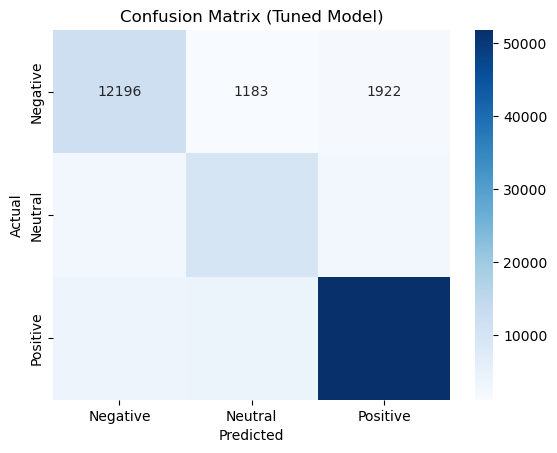


Multiclass ROC AUC (Tuned Model): 0.9212


In [17]:
# Run this after model_tuned has been trained

# Step 1: Predict on test set
y_pred_proba = model_tuned.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

# Step 2: Classification Report
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Step 3: Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("\nConfusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Tuned Model)")
plt.show()

# Step 4: ROC AUC
auc_score = roc_auc_score(y_test_cat, y_pred_proba, multi_class='ovr')
print(f"\nMulticlass ROC AUC (Tuned Model): {auc_score:.4f}")


In [18]:
from sklearn.metrics import classification_report
report_dict = classification_report(y_test, y_pred, target_names=label_encoder.classes_, output_dict=True)

model_summary = {
    'Model': 'Causal Transformer (Tuned)',
    'Embedding': 'Learnable (dim=256)',
    'Position Encoding': 'Learnable',
    'Heads': 8,
    'FF Dim': 512,
    'Dropout': 0.2,
    'Train Time (min)': 135.78,
    'Test Accuracy': f"{(y_pred == y_test).mean()*100:.2f}%",
    'F1 Positive': round(report_dict['Positive']['f1-score'], 4),
    'F1 Neutral': round(report_dict['Neutral']['f1-score'], 4),
    'F1 Negative': round(report_dict['Negative']['f1-score'], 4),
    'Macro F1': round(report_dict['macro avg']['f1-score'], 4),
    'AUC': round(auc_score, 4)
}

import pandas as pd
summary_df = pd.DataFrame([model_summary])
display(summary_df)


,Model,Embedding,Position Encoding,Heads,FF Dim,Dropout,Train Time (min),Test Accuracy,F1 Positive,F1 Neutral,F1 Negative,Macro F1,AUC
0,Causal Transformer (Tuned),Learnable (dim=256),Learnable,8,512,0.2,135.78,81.68%,0.8922,0.6422,0.7153,0.7499,0.9212


In [20]:
# Save in new Keras format (.keras)
model_tuned.save("causal_transformer_tuned.keras")

# Save in legacy HDF5 format (.h5)
model_tuned.save("causal_transformer_tuned.h5")


In [21]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import time

# New model hyperparameters
embedding_dim = 256
ff_dim = 512
num_heads = 8
dropout_rate = 0.2
epochs = 15
batch_size = 64

# Optional: label smoothing
label_smoothing_factor = 0.1

# Class weights (example - you can adjust based on class imbalance)
class_weights = {
    0: 1.2,   # Negative
    1: 1.5,   # Neutral
    2: 0.8    # Positive
}

# Two-layer causal transformer
class TwoLayerCausalTransformer(tf.keras.Model):
    def __init__(self, vocab_size, maxlen, embed_dim, num_heads, ff_dim, dropout):
        super().__init__()
        self.embedding = tf.keras.layers.Embedding(vocab_size, embed_dim)
        self.positional = LearnablePositionEncoding(maxlen, embed_dim)
        self.block1 = CausalTransformerBlock(embed_dim, num_heads, ff_dim, dropout)
        self.block2 = CausalTransformerBlock(embed_dim, num_heads, ff_dim, dropout)
        self.pool = tf.keras.layers.GlobalAveragePooling1D()
        self.drop = tf.keras.layers.Dropout(dropout)
        self.out = tf.keras.layers.Dense(3, activation='softmax')

    def call(self, x, training=False):
        x = self.embedding(x)
        x = self.positional(x)
        x = self.block1(x, training=training)
        x = self.block2(x, training=training)
        x = self.pool(x)
        x = self.drop(x, training=training)
        return self.out(x)

# Instantiate model
model_final = TwoLayerCausalTransformer(vocab_size, MAXLEN, embedding_dim, num_heads, ff_dim, dropout_rate)

# Compile with label smoothing
model_final.compile(
    optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing_factor),
    metrics=['accuracy']
)

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
lr_schedule = ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5, verbose=1)

# Train model
start_time = time.time()
history_final = model_final.fit(
    X_train, y_train_cat,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    class_weight=class_weights,
    callbacks=[early_stop, lr_schedule],
    verbose=1
)
end_time = time.time()
print(f"\n⏱️ Final Training Time: {(end_time - start_time) / 60:.2f} minutes")


Epoch 1/15
2592/2592 ━━━━━━━━━━━━━━━━━━━━ 4936s 2s/step - accuracy: 0.5754 - loss: 1.0974 - val_accuracy: 0.6974 - val_loss: 0.7804 - learning_rate: 0.0010
Epoch 2/15
2592/2592 ━━━━━━━━━━━━━━━━━━━━ 4605s 2s/step - accuracy: 0.7181 - loss: 0.8689 - val_accuracy: 0.6179 - val_loss: 0.8852 - learning_rate: 0.0010
Epoch 3/15
2592/2592 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7452 - loss: 0.8170
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2592/2592 ━━━━━━━━━━━━━━━━━━━━ 4552s 2s/step - accuracy: 0.7452 - loss: 0.8170 - val_accuracy: 0.6974 - val_loss: 0.7896 - learning_rate: 0.0010
Epoch 4/15
2592/2592 ━━━━━━━━━━━━━━━━━━━━ 4011s 2s/step - accuracy: 0.7666 - loss: 0.7904 - val_accuracy: 0.7134 - val_loss: 0.7750 - learning_rate: 5.0000e-04
Epoch 5/15
2592/2592 ━━━━━━━━━━━━━━━━━━━━ 4733s 2s/step - accuracy: 0.7920 - loss: 0.7438 - val_accuracy: 0.7192 - val_loss: 0.7574 - learning_rate: 5.0000e-04
Epoch 6/15
2592/2592 ━━━━━━━━━━━━━━━━━━━━ 4505s 2s/step - ac

In [22]:
# Save in Keras format (.keras)
model_final.save("causal_transformer_final.keras")

# Save in HDF5 format (.h5)
model_final.save("causal_transformer_final.h5")


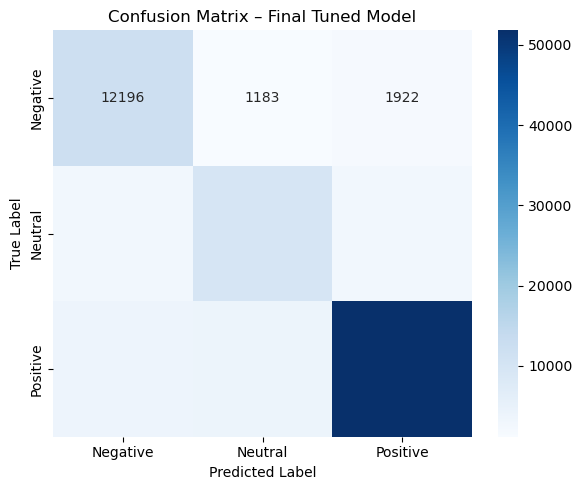

In [23]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Final Tuned Model")
plt.tight_layout()
plt.show()



In [24]:
from sklearn.metrics import classification_report

# Make sure you’ve already done:
# y_pred_proba = model_final.predict(X_test)
# y_pred = np.argmax(y_pred_proba, axis=1)

# Generate classification report
report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)
print("📊 Classification Report:\n")
print(report)

📊 Classification Report:

              precision    recall  f1-score   support

    Negative       0.65      0.80      0.72     15301
     Neutral       0.65      0.63      0.64     15358
    Positive       0.92      0.87      0.89     59608

    accuracy                           0.82     90267
   macro avg       0.74      0.77      0.75     90267
weighted avg       0.83      0.82      0.82     90267



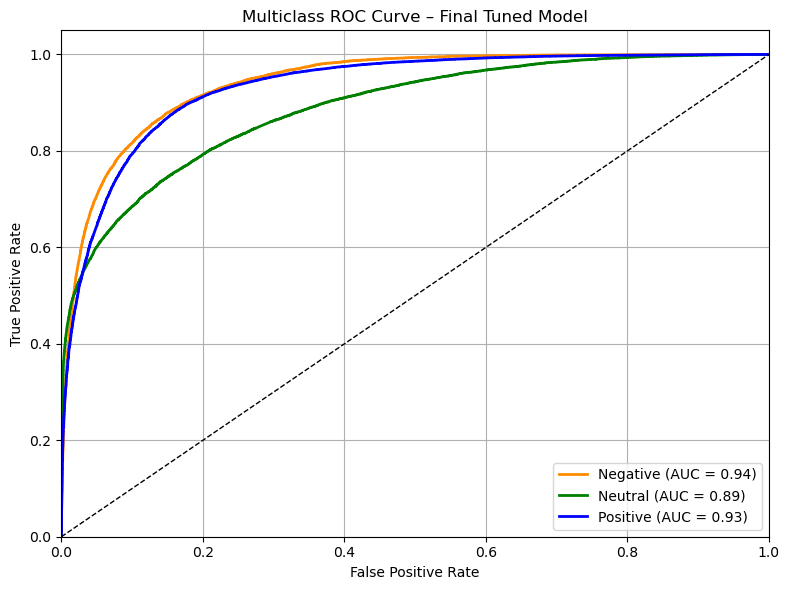

In [25]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Step 1: Binarize the true labels
# (Make sure class indices match your label encoder: [Negative=0, Neutral=1, Positive=2])
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])  # One-hot for AUC

# Step 2: Compute ROC curve and ROC area for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):  # 3 classes
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Step 3: Plot all ROC curves
plt.figure(figsize=(8, 6))
colors = ['darkorange', 'green', 'blue']
class_names = label_encoder.classes_  # ['Negative', 'Neutral', 'Positive']

for i in range(3):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve – Final Tuned Model")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


In [26]:
import pickle

# Save tokenizer to a pickle file
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)


In [28]:
# Save in Keras format (.keras)
model_final.save("causal_transformer_final.keras")

# Save in HDF5 format (.h5)
model_final.save("causal_transformer_final.h5")


In [29]:
import zipfile

with zipfile.ZipFile("causal_transformer_submission.zip", "w") as zipf:
    zipf.write("causal_transformer_final.keras")
    zipf.write("causal_transformer_final.h5")
    zipf.write("tokenizer.pkl")

print("✅ Zipped file created: causal_transformer_submission.zip")


✅ Zipped file created: causal_transformer_submission.zip


In [31]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

# Define model builder (1-layer causal transformer version)
def build_causal_transformer(vocab_size, maxlen, embedding_dim, ff_dim, num_heads, dropout_rate):
    inputs = tf.keras.Input(shape=(maxlen,))
    embedding = tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim)(inputs)
    pos_encoding = LearnablePositionEncoding(maxlen, embedding_dim)(embedding)
    transformer = CausalTransformerBlock(embedding_dim, num_heads, ff_dim, dropout_rate)(pos_encoding, training=True)
    pooled = tf.keras.layers.GlobalAveragePooling1D()(transformer)
    dropout = tf.keras.layers.Dropout(dropout_rate)(pooled)
    outputs = tf.keras.layers.Dense(3, activation='softmax')(dropout)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Hyperparameters
embedding_dim = 128
ff_dim = 256
num_heads = 4
dropout_rate = 0.2

# Setup StratifiedKFold
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
fold = 1

for train_idx, val_idx in skf.split(X_train, y_train):
    print(f"\n🔁 Fold {fold}")
    
    model = build_causal_transformer(vocab_size, MAXLEN, embedding_dim, ff_dim, num_heads, dropout_rate)
    
    model.fit(X_train[train_idx], y_train_cat[train_idx],
              validation_data=(X_train[val_idx], y_train_cat[val_idx]),
              epochs=3, batch_size=64, verbose=1)
    
    fold += 1



🔁 Fold 1
Epoch 1/3
1920/1920 ━━━━━━━━━━━━━━━━━━━━ 485s 247ms/step - accuracy: 0.6144 - loss: 0.8519 - val_accuracy: 0.7323 - val_loss: 0.6303
Epoch 2/3
1920/1920 ━━━━━━━━━━━━━━━━━━━━ 389s 202ms/step - accuracy: 0.7775 - loss: 0.5283 - val_accuracy: 0.7491 - val_loss: 0.6144
Epoch 3/3
1920/1920 ━━━━━━━━━━━━━━━━━━━━ 365s 190ms/step - accuracy: 0.8259 - loss: 0.4259 - val_accuracy: 0.7523 - val_loss: 0.6270

🔁 Fold 2
Epoch 1/3
1920/1920 ━━━━━━━━━━━━━━━━━━━━ 372s 186ms/step - accuracy: 0.6119 - loss: 0.8581 - val_accuracy: 0.7290 - val_loss: 0.6269
Epoch 2/3
1920/1920 ━━━━━━━━━━━━━━━━━━━━ 357s 186ms/step - accuracy: 0.7721 - loss: 0.5377 - val_accuracy: 0.7466 - val_loss: 0.6111
Epoch 3/3
1920/1920 ━━━━━━━━━━━━━━━━━━━━ 357s 186ms/step - accuracy: 0.8221 - loss: 0.4323 - val_accuracy: 0.7376 - val_loss: 0.6602

🔁 Fold 3
Epoch 1/3
1920/1920 ━━━━━━━━━━━━━━━━━━━━ 371s 187ms/step - accuracy: 0.6109 - loss: 0.8476 - val_accuracy: 0.7343 - val_loss: 0.6127
Epoch 2/3
1920/1920 ━━━━━━━━━━━━━━━━━━━

In [33]:
import pickle
import zipfile

# ✅ Save model in .keras format
model_final.save("causal_transformer_final.keras")

# ✅ Save model in .h5 format
model_final.save("causal_transformer_final.h5")

# ✅ Save tokenizer as .pkl
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

# ✅ Zip all files
with zipfile.ZipFile("causal_transformer_submission.zip", "w") as zipf:
    zipf.write("causal_transformer_final.keras")
    zipf.write("causal_transformer_final.h5")
    zipf.write("tokenizer.pkl")

print("✅ All files saved and zipped successfully.")


✅ All files saved and zipped successfully.


2821/2821 ━━━━━━━━━━━━━━━━━━━━ 87s 31ms/step


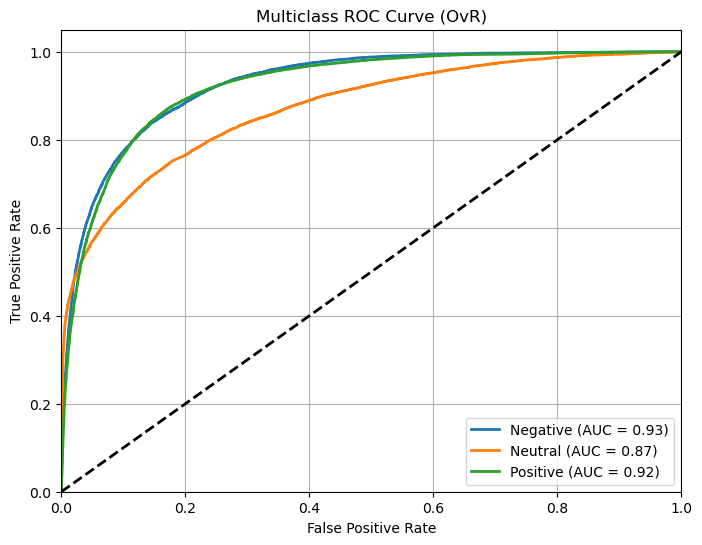

In [41]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Ensure labels are one-hot (you likely already have this)
# y_test_cat = to_categorical(y_test, num_classes=3)

# Predict probabilities
y_pred_proba = model.predict(X_test)

# Get class labels
class_names = label_encoder.classes_  # ['Negative', 'Neutral', 'Positive']

# Plot settings
plt.figure(figsize=(8, 6))

for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(y_test_cat[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve (OvR)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [42]:
class CausalTransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation='relu'),
            tf.keras.layers.Dense(embed_dim)
        ])
        self.norm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(dropout)
        self.dropout2 = tf.keras.layers.Dropout(dropout)

    def call(self, inputs, training=None, return_attention=False):
        mask = tf.linalg.band_part(tf.ones((tf.shape(inputs)[1], tf.shape(inputs)[1])), -1, 0)
        attn_output, attn_scores = self.att(
            inputs, inputs, attention_mask=mask, return_attention_scores=True)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.norm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.norm2(out1 + ffn_output)

        if return_attention:
            return out2, attn_scores
        else:
            return out2


In [43]:
import tensorflow as tf
import numpy as np

# Example input: batch of 1 sentence with 10 tokens, embedding dim 128
dummy_input = tf.random.uniform((1, 10, 128))  # (batch_size, seq_len, embed_dim)

# Instantiate the block
transformer_block = CausalTransformerBlock(embed_dim=128, num_heads=4, ff_dim=256)

# Run the block and get attention scores
output, attn_scores = transformer_block(dummy_input, training=False, return_attention=True)

print("✅ Output shape:", output.shape)
print("🔍 Attention scores shape:", attn_scores.shape)


✅ Output shape: (1, 10, 128)
🔍 Attention scores shape: (1, 4, 10, 10)


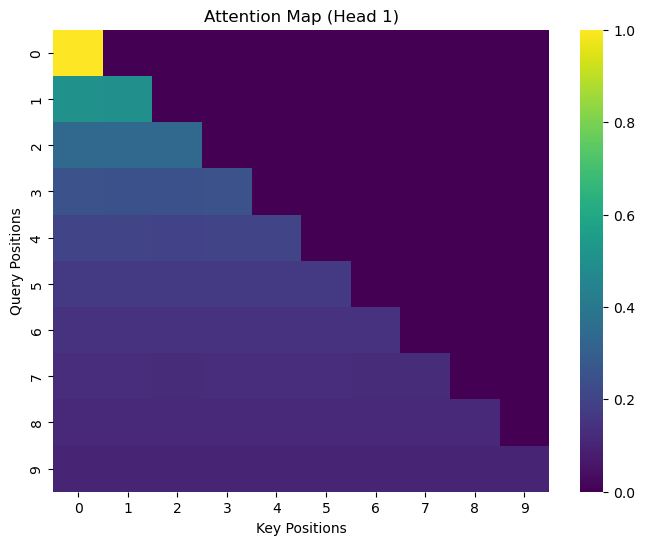

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select one head's attention
single_head_attn = attn_scores[0, 0]  # (query_len, key_len)

plt.figure(figsize=(8, 6))
sns.heatmap(single_head_attn.numpy(), cmap="viridis", annot=False)
plt.title("Attention Map (Head 1)")
plt.xlabel("Key Positions")
plt.ylabel("Query Positions")
plt.show()


In [45]:
import pickle
import zipfile

# ✅ Save model in .keras format
model_final.save("causal_transformer_final.keras")

# ✅ Save model in .h5 format
model_final.save("causal_transformer_final.h5")

# ✅ Save tokenizer as .pkl
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

# ✅ Zip all files
with zipfile.ZipFile("causal_transformer_submission.zip", "w") as zipf:
    zipf.write("causal_transformer_final.keras")
    zipf.write("causal_transformer_final.h5")
    zipf.write("tokenizer.pkl")

print("✅ All files saved and zipped successfully.")


✅ All files saved and zipped successfully.


In [46]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Sample tweets to test the model
sample_texts = [
    "I am so happy today! Life is beautiful 😄",   # clearly positive
    "I'm not sure how I feel about this...",       # neutral or uncertain
    "This is the worst experience I've ever had",  # clearly negative
    "Great service, but the food was terrible.",   # mixed
    "Just an ordinary day, nothing special.",      # neutral
    "Absolutely love this product! Highly recommend.", # strong positive
    "Terrible customer support. Not coming back.", # strong negative
]

# Preprocess: tokenize and pad
sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded = pad_sequences(sample_sequences, maxlen=MAXLEN, padding='post')

# Predict
sample_probs = model.predict(sample_padded)
sample_preds = np.argmax(sample_probs, axis=1)
decoded_preds = label_encoder.inverse_transform(sample_preds)

# Show predictions
for i, text in enumerate(sample_texts):
    print(f"📝 Tweet: {text}")
    print(f"🔍 Predicted Sentiment: {decoded_preds[i]}  |  Probabilities: {sample_probs[i]}")
    print("------------------------------------------------")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
📝 Tweet: I am so happy today! Life is beautiful 😄
🔍 Predicted Sentiment: Positive  |  Probabilities: [0.0023254  0.00892907 0.9887455 ]
------------------------------------------------
📝 Tweet: I'm not sure how I feel about this...
🔍 Predicted Sentiment: Neutral  |  Probabilities: [0.12458156 0.74757415 0.12784432]
------------------------------------------------
📝 Tweet: This is the worst experience I've ever had
🔍 Predicted Sentiment: Negative  |  Probabilities: [9.8195672e-01 1.7835129e-02 2.0807379e-04]
------------------------------------------------
📝 Tweet: Great service, but the food was terrible.
🔍 Predicted Sentiment: Neutral  |  Probabilities: [0.2157371  0.7365357  0.04772717]
------------------------------------------------
📝 Tweet: Just an ordinary day, nothing special.
🔍 Predicted Sentiment: Neutral  |  Probabilities: [0.03242483 0.7822102  0.18536502]
------------------------------------------------
📝 Tweet: Absolutely love this pro

In [49]:
pip install lime


Note: you may need to restart the kernel to use updated packages.


In [50]:
from lime.lime_text import LimeTextExplainer
import numpy as np

# Define a class name list (in order of label encoder classes)
class_names = label_encoder.classes_.tolist()

# Define a wrapper function for the model's probability output
def predict_proba(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    padded = pad_sequences(seqs, maxlen=MAXLEN, padding='post')
    return model_final.predict(padded)


In [51]:
explainer = LimeTextExplainer(class_names=class_names)


In [78]:
sample_tweet = "I love the performance, but the ending was disappointing."

# Generate explanation
exp = explainer.explain_instance(sample_tweet, predict_proba, num_features=10, top_labels=3)

# Visualize in notebook
exp.show_in_notebook(text=sample_tweet)


157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 254ms/step


In [79]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Sample tweets to test the model
sample_texts = [
    "I love the performance, but the ending was disappointing."
    
]

# Preprocess: tokenize and pad
sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded = pad_sequences(sample_sequences, maxlen=MAXLEN, padding='post')

# Predict
sample_probs = model.predict(sample_padded)
sample_preds = np.argmax(sample_probs, axis=1)
decoded_preds = label_encoder.inverse_transform(sample_preds)

# Show predictions
for i, text in enumerate(sample_texts):
    print(f"📝 Tweet: {text}")
    print(f"🔍 Predicted Sentiment: {decoded_preds[i]}  |  Probabilities: {sample_probs[i]}")
    print("------------------------------------------------")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
📝 Tweet: I love the performance, but the ending was disappointing.
🔍 Predicted Sentiment: Neutral  |  Probabilities: [0.12244032 0.79936147 0.07819815]
------------------------------------------------


In [ ]:
# first prompt: Eplain me how it works and steps for it  Causal transformer model using learnable embedding layer and position encodings
# last prompt: how can I tune model give me best possible ways